In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
import optuna

In [5]:
df = pd.read_csv("/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/data/processed/Evening_Snacks_feature_2024_2025.csv", parse_dates=["Date"])
holdout_df = pd.read_csv("/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/data/processed/Evening_Snacks_feature_2026.csv", parse_dates=["Date"])

In [6]:
df.shape

(731, 46)

In [7]:
df.head()

,Date,DayOfWeek,DayOfMonth,Month,Is_Start_Of_Month,Is_End_Of_Month,Is_Weekend,Is_Holiday,Is_Vacation,Is_Exam_Period,...,Target_14_Day_Std,Target_14_Day_Max,Target_14_Day_Min,Target_28_Day_Avg,Target_28_Day_Std,Target_28_Day_Max,Target_28_Day_Min,Target_EWMA_7,Target_EWMA_14,Trend_7_vs_28
0,2024-01-01,Monday,1,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,Tuesday,2,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.000000,NaN
2,2024-01-03,Wednesday,3,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,5.066667,NaN
3,2024-01-04,Thursday,4,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,7.857778,NaN
4,2024-01-05,Friday,5,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,10.410074,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                731 non-null    datetime64[us]
 1   DayOfWeek           731 non-null    str           
 2   DayOfMonth          731 non-null    int64         
 3   Month               731 non-null    int64         
 4   Is_Start_Of_Month   731 non-null    int64         
 5   Is_End_Of_Month     731 non-null    int64         
 6   Is_Weekend          731 non-null    int64         
 7   Is_Holiday          731 non-null    int64         
 8   Is_Vacation         731 non-null    int64         
 9   Is_Exam_Period      731 non-null    int64         
 10  Is_Fest             731 non-null    int64         
 11  Days_Until_Holiday  731 non-null    float64       
 12  DayOfWeek_Sin       731 non-null    float64       
 13  DayOfWeek_Cos       731 non-null    float64       
 14  Month

In [9]:
df_clean = df.dropna().reset_index(drop=True)
print(len(df), ",", len(df_clean))

731 , 601


In [10]:
feature_cols = [c for c in df_clean.columns if c not in ["Date", "Target_Headcount", "Category", "Notes", "DayOfWeek"]]

X = df_clean[feature_cols]
Y = df_clean["Target_Headcount"]

In [11]:
train_mask = df_clean["Date"].dt.year == 2024
validate_mask = df_clean["Date"].dt.year == 2025

X_train, Y_train = X[train_mask], Y[train_mask]
X_validate, Y_validate = X[validate_mask], Y[validate_mask]

print(len(X_train), len(Y_train), "\n", len(X_validate), len(Y_validate))

256 256 
 345 345


In [12]:
print(X_train.shape)
print(X_validate.shape)

print(df_clean.loc[train_mask, "Date"].min(), df_clean.loc[train_mask, "Date"].max())
print(df_clean.loc[validate_mask, "Date"].min(), df_clean.loc[validate_mask, "Date"].max())

(256, 43)
(345, 43)
2024-01-29 00:00:00 2024-12-07 00:00:00
2025-01-21 00:00:00 2025-12-31 00:00:00


In [13]:
print(X_train.iloc[100])

DayOfMonth              8.000000
Month                   5.000000
Is_Start_Of_Month       0.000000
Is_End_Of_Month         0.000000
Is_Weekend              0.000000
Is_Holiday              0.000000
Is_Vacation             0.000000
Is_Exam_Period          1.000000
Is_Fest                 0.000000
Days_Until_Holiday     99.000000
DayOfWeek_Sin           0.974928
DayOfWeek_Cos          -0.222521
Month_Sin               0.500000
Month_Cos              -0.866025
Is_Broke_Weekend        0.000000
Is_Rich_Weekend         0.000000
WeekOfYear             19.000000
DayOfYear             129.000000
Target_1_Days_Ago      42.000000
Target_2_Days_Ago      53.000000
Target_3_Days_Ago      67.000000
Target_7_Days_Ago      44.000000
Target_14_Days_Ago    134.000000
Target_21_Days_Ago     92.000000
Target_3_Day_Avg       54.000000
Target_3_Day_Std       12.529964
Target_3_Day_Max       67.000000
Target_3_Day_Min       42.000000
Target_7_Day_Avg       58.000000
Target_7_Day_Std       14.787382
Target_7_D

In [14]:
check_date = df_clean[df_clean["Date"] == "2024-08-10"]
print(check_date[["Date", "Target_Headcount", "Target_7_Days_Ago"]])

seven_days_before = df_clean[df_clean["Date"] == "2024-08-03"]
print(seven_days_before[["Date", "Target_Headcount"]])

          Date  Target_Headcount  Target_7_Days_Ago
136 2024-08-10              12.0               55.0
          Date  Target_Headcount
129 2024-08-03              55.0


In [15]:
window = df_clean[df_clean["Date"].between("2024-03-09", "2024-03-15")]
print(window[["Date", "Target_Headcount"]])
print("Manual 7-day avg:", window["Target_Headcount"].mean())

print("Target_7_Day_Avg column says:", df_clean[df_clean["Date"] == "2024-03-16"]["Target_7_Day_Avg"].values)

         Date  Target_Headcount
40 2024-03-09              53.0
41 2024-03-10              42.0
42 2024-03-11             123.0
43 2024-03-12             105.0
44 2024-03-13             135.0
45 2024-03-14             169.0
46 2024-03-15              68.0
Manual 7-day avg: 99.28571428571429
Target_7_Day_Avg column says: [99.28571429]


In [16]:
"Target_Headcount" in feature_cols

False

In [17]:
X_train.isna().sum().sum()
X_validate.isna().sum().sum()

np.int64(0)

In [18]:
print(len(feature_cols))
print(feature_cols)

43
['DayOfMonth', 'Month', 'Is_Start_Of_Month', 'Is_End_Of_Month', 'Is_Weekend', 'Is_Holiday', 'Is_Vacation', 'Is_Exam_Period', 'Is_Fest', 'Days_Until_Holiday', 'DayOfWeek_Sin', 'DayOfWeek_Cos', 'Month_Sin', 'Month_Cos', 'Is_Broke_Weekend', 'Is_Rich_Weekend', 'WeekOfYear', 'DayOfYear', 'Target_1_Days_Ago', 'Target_2_Days_Ago', 'Target_3_Days_Ago', 'Target_7_Days_Ago', 'Target_14_Days_Ago', 'Target_21_Days_Ago', 'Target_3_Day_Avg', 'Target_3_Day_Std', 'Target_3_Day_Max', 'Target_3_Day_Min', 'Target_7_Day_Avg', 'Target_7_Day_Std', 'Target_7_Day_Max', 'Target_7_Day_Min', 'Target_14_Day_Avg', 'Target_14_Day_Std', 'Target_14_Day_Max', 'Target_14_Day_Min', 'Target_28_Day_Avg', 'Target_28_Day_Std', 'Target_28_Day_Max', 'Target_28_Day_Min', 'Target_EWMA_7', 'Target_EWMA_14', 'Trend_7_vs_28']


In [19]:
model = RandomForestRegressor(random_state=28)

In [20]:
model.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",28
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [21]:
prediction = model.predict(X_validate)

In [22]:
mae = mean_absolute_error(Y_validate, prediction)
rmse = np.sqrt(mean_squared_error(Y_validate, prediction))

baseline_pred = X_validate["Target_7_Days_Ago"]
actual = Y_validate
mask = baseline_pred.notna() & actual.notna()
baseline_mae = (actual[mask] - baseline_pred[mask]).abs().mean()
baseline_rmse = np.sqrt(mean_squared_error(actual[mask], baseline_pred[mask]))

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Model MAE:", mae)
print("Model RMSE:", rmse)

Baseline MAE: 36.39710144927536
Baseline RMSE: 55.337567499950644
Model MAE: 32.39631884057971
Model RMSE: 39.69411153716175


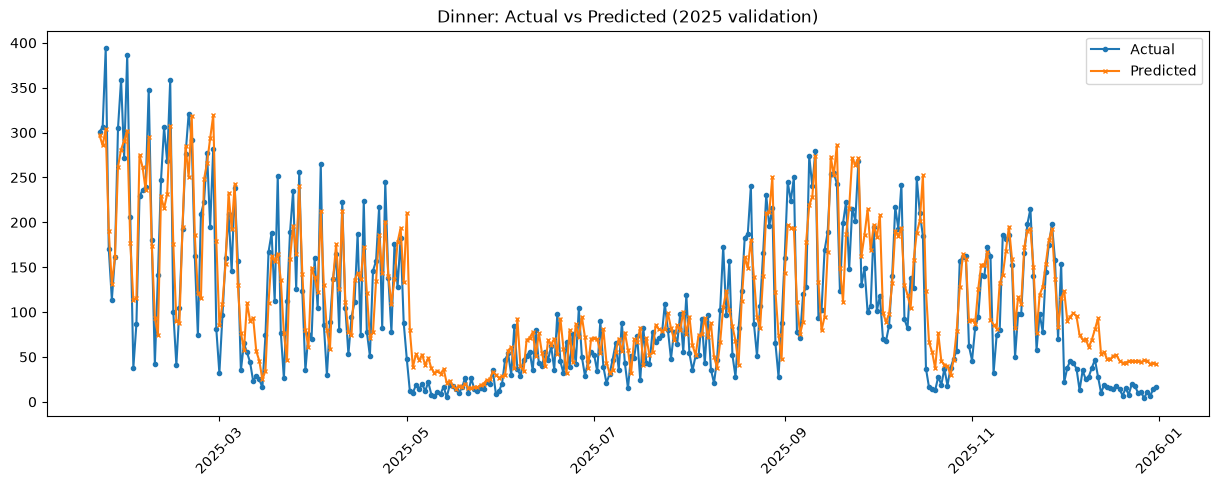

In [23]:
val_dates = df_clean.loc[validate_mask, "Date"]

plt.figure(figsize=(15,5))
plt.plot(val_dates, Y_validate.values, label="Actual", marker='o', markersize=3)
plt.plot(val_dates, prediction, label="Predicted", marker='x', markersize=3)
plt.legend()
plt.title("Dinner: Actual vs Predicted (2025 validation)")
plt.xticks(rotation=45)
plt.show()

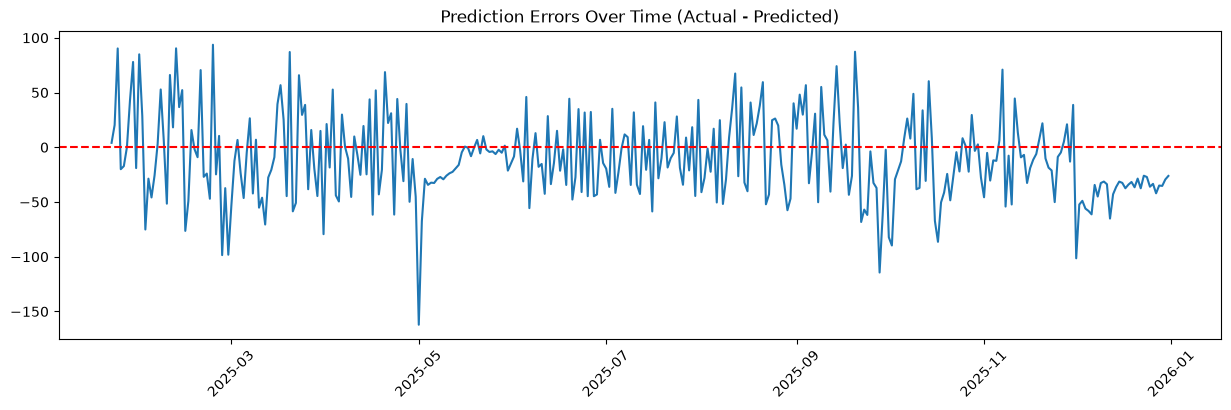

In [24]:
residuals = Y_validate.values - prediction

plt.figure(figsize=(15,4))
plt.plot(val_dates, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Prediction Errors Over Time (Actual - Predicted)")
plt.xticks(rotation=45)
plt.show()

In [25]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15)

Target_7_Days_Ago     0.465197
Target_1_Days_Ago     0.178827
Target_14_Days_Ago    0.045046
Days_Until_Holiday    0.027480
Target_EWMA_7         0.027384
Trend_7_vs_28         0.023106
Target_21_Days_Ago    0.022398
DayOfWeek_Sin         0.019435
Target_3_Day_Std      0.016149
Target_28_Day_Std     0.012718
Target_7_Day_Avg      0.012485
Target_3_Day_Min      0.012347
Target_3_Day_Max      0.011885
DayOfYear             0.011312
DayOfMonth            0.009905
dtype: float64

In [26]:
df_sorted = df_clean.sort_values("Date").reset_index(drop=True)

fold_windows = [
    ("2024-01-01", "2024-12-31", "2025-01-01", "2025-03-01"),
    ("2024-01-01", "2025-03-01", "2025-03-01", "2025-05-01"),
    ("2024-01-01", "2025-05-01", "2025-05-01", "2025-07-01"),
    ("2024-01-01", "2025-07-01", "2025-07-01", "2025-09-01"),
    ("2024-01-01", "2025-09-01", "2025-09-01", "2025-11-01"),
    ("2024-01-01", "2025-11-01", "2025-11-01", "2025-12-31"),
]
results = []

for name, ModelClass, params in [
    ("RandomForest", RandomForestRegressor, {"random_state":28}),
    ("XGBoost", XGBRegressor, {"random_state": 28}),
    ("LightGBM", LGBMRegressor, {"random_state": 28, "verbose": -1}),
    ("CatBoost", CatBoostRegressor, {"random_state": 28, "verbose": 0}),
]:
    fold_MAEs = []
    fold_RMSEs = []
    
    for train_start, train_end, val_start, val_end in fold_windows:
        
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        
        model = ModelClass(**params)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_MAEs.append(mean_absolute_error(val_fold["Target_Headcount"], pred))
        fold_RMSEs.append(np.sqrt(mean_squared_error(val_fold["Target_Headcount"], pred)))
        
    results.append({
        "Model": name,
        "MAE": np.mean(fold_MAEs),
        "MAE STD": np.std(fold_MAEs),
        "RMSE": np.mean(fold_RMSEs),
        "RMSE STD": np.std(fold_RMSEs),
    })

    print(f"{name}")
    print(f"Average MAE  : {np.mean(fold_MAEs):.2f} ± {np.std(fold_MAEs):.2f}")
    print(f"Average RMSE : {np.mean(fold_RMSEs):.2f} ± {np.std(fold_RMSEs):.2f}")
    print(f"Fold MAEs    : {[round(float(x),1) for x in fold_MAEs]}")
    print(f"Fold RMSEs   : {[round(float(x),1) for x in fold_RMSEs]}")
    print()

RandomForest
Average MAE  : 31.96 ± 6.74
Average RMSE : 39.83 ± 7.88
Fold MAEs    : [42.1, 33.9, 27.4, 20.5, 35.7, 32.3]
Fold RMSEs   : [51.8, 39.2, 39.5, 25.8, 45.0, 37.7]

XGBoost
Average MAE  : 38.86 ± 12.35
Average RMSE : 47.66 ± 13.81
Fold MAEs    : [52.4, 36.0, 32.1, 18.2, 39.9, 54.6]
Fold RMSEs   : [60.6, 42.6, 42.8, 22.8, 52.8, 64.4]

LightGBM
Average MAE  : 32.45 ± 7.39
Average RMSE : 40.32 ± 9.12
Fold MAEs    : [42.9, 36.6, 32.0, 18.6, 34.2, 30.4]
Fold RMSEs   : [52.0, 43.9, 41.9, 22.9, 45.3, 35.8]

CatBoost
Average MAE  : 33.90 ± 12.79
Average RMSE : 41.67 ± 15.03
Fold MAEs    : [58.6, 36.6, 24.7, 17.4, 34.4, 31.8]
Fold RMSEs   : [71.3, 42.9, 35.3, 21.3, 41.8, 37.3]



In [27]:
def objective(trial):
    parameters = {
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 12),  # widened from 8

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        
        "random_state": 28,
        "n_jobs": -1,
    }

    fold_maes = []
    for train_start, train_end, val_start, val_end in fold_windows:
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        model = XGBRegressor(**parameters)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_maes.append(mean_absolute_error(val_fold["Target_Headcount"], pred))

    return np.mean(fold_maes)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=28, multivariate=True, group=True)
)
study.optimize(objective, n_trials=400, show_progress_bar=True)  # bumped from 100

print("\nBest MAE:")
print(f"{study.best_value:.2f}")
print("\nBest Parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")
print("\nTop 10 Trials:")
display(study.trials_dataframe().sort_values("value").head(10))

/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-11 22:30:03,730] A new study created in memory with name: no-name-dfa84902-3b30-4f83-80dc-f8c65a808f5e


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-07-11 22:30:05,724] Trial 0 finished with value: 32.53626574070319 and parameters: {'learning_rate': 0.09891603549518685, 'n_estimators': 493, 'max_depth': 4, 'min_child_weight': 6, 'gamma': 3.9065410313673805, 'reg_alpha': 0.11065522526191614, 'reg_lambda': 0.005379890467195983, 'subsample': 0.9267564376244264, 'colsample_bytree': 0.9776859463174046}. Best is trial 0 with value: 32.53626574070319.
[I 2026-07-11 22:30:07,195] Trial 1 finished with value: 36.20517932860664 and parameters: {'learning_rate': 0.2812227258994409, 'n_estimators': 235, 'max_depth': 12, 'min_child_weight': 4, 'gamma': 0.1317692425493533, 'reg_alpha': 6.0847308477212225, 'reg_lambda': 4.862945563972716, 'subsample': 0.6469878839059903, 'colsample_bytree': 0.5831368510995121}. Best is trial 0 with value: 32.53626574070319.
[I 2026-07-11 22:30:09,894] Trial 2 finished with value: 31.153383691150953 and parameters: {'learning_rate': 0.02524013197544389, 'n_estimators': 457, 'max_depth': 6, 'min_child_weigh

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state
278,278,29.056815,2026-07-11 22:47:46.589881,2026-07-11 22:47:48.680192,0 days 00:00:02.090311,0.972221,4.019778,0.018709,8,5,218,0.429964,0.023900,0.507944,COMPLETE
34,34,29.146033,2026-07-11 22:32:22.049801,2026-07-11 22:32:24.360050,0 days 00:00:02.310249,0.838877,4.596386,0.016975,5,6,507,0.062585,0.283301,0.517855,COMPLETE
344,344,29.161186,2026-07-11 22:51:01.449644,2026-07-11 22:51:02.995955,0 days 00:00:01.546311,0.993635,3.997454,0.046493,9,8,182,0.006585,0.020621,0.528914,COMPLETE
397,397,29.254035,2026-07-11 22:54:15.599057,2026-07-11 22:54:17.796086,0 days 00:00:02.197029,0.979370,2.729503,0.038830,7,10,292,0.016555,0.069879,0.515266,COMPLETE
345,345,29.256765,2026-07-11 22:51:02.999421,2026-07-11 22:51:04.807171,0 days 00:00:01.807750,0.962276,4.258535,0.041610,11,7,178,0.004206,0.003136,0.558554,COMPLETE
27,27,29.281940,2026-07-11 22:31:52.447709,2026-07-11 22:31:58.427250,0 days 00:00:05.979541,0.961863,2.570746,0.036868,8,6,731,0.019902,0.005315,0.511383,COMPLETE
70,70,29.314966,2026-07-11 22:34:23.276694,2026-07-11 22:34:24.365292,0 days 00:00:01.088598,0.862859,4.733417,0.038703,6,7,187,0.037307,0.523340,0.556736,COMPLETE
226,226,29.334777,2026-07-11 22:44:29.792389,2026-07-11 22:44:38.714587,0 days 00:00:08.922198,0.976419,2.568872,0.015316,6,8,503,0.001645,0.029255,0.575201,COMPLETE
263,263,29.384065,2026-07-11 22:46:42.537909,2026-07-11 22:46:50.770588,0 days 00:00:08.232679,0.948610,3.270107,0.012201,6,8,481,0.001744,0.019146,0.634565,COMPLETE
124,124,29.393768,2026-07-11 22:37:26.752943,2026-07-11 22:37:28.627753,0 days 00:00:01.874810,0.905364,4.025393,0.019702,9,9,299,0.268648,0.027135,0.535043,COMPLETE


In [28]:
def objective_lgbm(trial):
    parameters = {
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),

        "num_leaves": trial.suggest_int("num_leaves", 15, 255),   # widened from 127
        "max_depth": trial.suggest_int("max_depth", 3, 12),        # widened from 10
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 40),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": 1,

        "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 10, log=True),

        "random_state": 28,
        "verbose": -1,
        "n_jobs": -1,
    }

    fold_maes = []
    for train_start, train_end, val_start, val_end in fold_windows:
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        model = LGBMRegressor(**parameters)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_maes.append(mean_absolute_error(val_fold["Target_Headcount"], pred))

    return np.mean(fold_maes)

study_lgbm = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=28, multivariate=True, group=True)
)
study_lgbm.optimize(objective_lgbm, n_trials=400, show_progress_bar=True)

print("\nBest MAE:")
print(f"{study_lgbm.best_value:.2f}")
print("\nBest Parameters:")
for key, value in study_lgbm.best_params.items():
    print(f"{key}: {value}")
print("\nTop 10 Trials:")
display(study_lgbm.trials_dataframe().sort_values("value").head(10))

/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-11 22:54:27,852] A new study created in memory with name: no-name-2e90d24f-a009-4455-babc-e4eb47ff2963


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-07-11 22:54:28,507] Trial 0 finished with value: 35.05358392977996 and parameters: {'learning_rate': 0.09891603549518685, 'n_estimators': 493, 'num_leaves': 45, 'max_depth': 6, 'min_child_samples': 33, 'feature_fraction': 0.7554964908265566, 'bagging_fraction': 0.5913466792079125, 'lambda_l1': 2.5944870122202537, 'lambda_l2': 6.629603735454784}. Best is trial 0 with value: 35.05358392977996.
[I 2026-07-11 22:54:29,168] Trial 1 finished with value: 32.27900140094835 and parameters: {'learning_rate': 0.2812227258994409, 'n_estimators': 235, 'num_leaves': 248, 'max_depth': 5, 'min_child_samples': 5, 'feature_fraction': 0.9730301715484778, 'bagging_fraction': 0.9608624260104734, 'lambda_l1': 0.01499350163142072, 'lambda_l2': 0.004624819726550633}. Best is trial 1 with value: 32.27900140094835.
[I 2026-07-11 22:54:29,901] Trial 2 finished with value: 31.974361730612586 and parameters: {'learning_rate': 0.02524013197544389, 'n_estimators': 457, 'num_leaves': 89, 'max_depth': 7, 'min_

,number,value,datetime_start,datetime_complete,duration,params_bagging_fraction,params_feature_fraction,params_lambda_l1,params_lambda_l2,params_learning_rate,params_max_depth,params_min_child_samples,params_n_estimators,params_num_leaves,state
185,185,29.435916,2026-07-11 23:00:56.656412,2026-07-11 23:00:58.076706,0 days 00:00:01.420294,0.724181,0.894287,7.657827,0.124189,0.026312,6,9,494,247,COMPLETE
174,174,29.469319,2026-07-11 23:00:38.401675,2026-07-11 23:00:39.719731,0 days 00:00:01.318056,0.756583,0.992198,0.013299,0.003144,0.021394,5,6,354,158,COMPLETE
348,348,29.518619,2026-07-11 23:05:26.419089,2026-07-11 23:05:30.066618,0 days 00:00:03.647529,0.793841,0.999068,0.157124,0.001870,0.018071,10,6,710,129,COMPLETE
336,336,29.571546,2026-07-11 23:05:08.307318,2026-07-11 23:05:09.275313,0 days 00:00:00.967995,0.653870,0.980444,0.019061,0.007728,0.015964,6,13,403,124,COMPLETE
150,150,29.659317,2026-07-11 22:59:52.535892,2026-07-11 22:59:55.054753,0 days 00:00:02.518861,0.542140,0.885748,0.219763,0.064300,0.009650,9,8,790,159,COMPLETE
218,218,29.682247,2026-07-11 23:02:06.742150,2026-07-11 23:02:08.355078,0 days 00:00:01.612928,0.648518,0.968278,0.620883,0.021406,0.013379,6,9,585,156,COMPLETE
227,227,29.693650,2026-07-11 23:02:21.808932,2026-07-11 23:02:23.061430,0 days 00:00:01.252498,0.559963,0.901071,1.995573,0.027579,0.015196,6,8,469,104,COMPLETE
88,88,29.741267,2026-07-11 22:57:41.200079,2026-07-11 22:57:44.162836,0 days 00:00:02.962757,0.650977,0.985552,2.088322,0.010068,0.019780,9,5,567,163,COMPLETE
274,274,29.757085,2026-07-11 23:03:32.381503,2026-07-11 23:03:35.472713,0 days 00:00:03.091210,0.702699,0.982422,0.390143,0.019724,0.008773,10,6,596,186,COMPLETE
130,130,29.758147,2026-07-11 22:59:19.864082,2026-07-11 22:59:21.130605,0 days 00:00:01.266523,0.706614,0.979607,0.017720,0.004008,0.011700,6,7,361,119,COMPLETE


In [29]:
def objective_cb(trial):
    parameters = {
        "loss_function": "RMSE",
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "iterations": trial.suggest_int("iterations", 100, 800),
        "depth": trial.suggest_int("depth", 1, 10),  # widened from 3

        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
        "random_strength": trial.suggest_float("random_strength", 0.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 10.0),

        "random_seed": 28,
        "verbose": 0,
    }

    fold_maes = []
    for train_start, train_end, val_start, val_end in fold_windows:
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        model = CatBoostRegressor(**parameters)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_maes.append(mean_absolute_error(val_fold["Target_Headcount"], pred))

    return np.mean(fold_maes)

study_cb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=28, multivariate=True, group=True)
)
study_cb.optimize(objective_cb, n_trials=400, show_progress_bar=True)

print("\nBest MAE:")
print(f"{study_cb.best_value:.2f}")
print("\nBest Parameters:")
for key, value in study_cb.best_params.items():
    print(f"{key}: {value}")
print("\nTop 10 Trials:")
display(study_cb.trials_dataframe().sort_values("value").head(10))

/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-11 23:07:02,816] A new study created in memory with name: no-name-a53ae5fe-10d2-4515-a621-e75ba076cf9e


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-07-11 23:07:04,150] Trial 0 finished with value: 33.84161541275238 and parameters: {'learning_rate': 0.09891603549518685, 'iterations': 493, 'depth': 2, 'l2_leaf_reg': 8.554255005302226, 'random_strength': 7.813082062734761, 'bagging_temperature': 5.109929816531132}. Best is trial 0 with value: 33.84161541275238.
[I 2026-07-11 23:08:48,325] Trial 1 finished with value: 45.17978049133504 and parameters: {'learning_rate': 0.010563952214732381, 'iterations': 698, 'depth': 10, 'l2_leaf_reg': 19.700055896783798, 'random_strength': 1.9270097382736828, 'bagging_temperature': 9.707951013702171}. Best is trial 0 with value: 33.84161541275238.
[I 2026-07-11 23:09:05,576] Trial 2 finished with value: 63.21430099956797 and parameters: {'learning_rate': 0.013076598023598389, 'iterations': 118, 'depth': 10, 'l2_leaf_reg': 18.51277218839799, 'random_strength': 2.9397576781198054, 'bagging_temperature': 1.6627370219902426}. Best is trial 0 with value: 33.84161541275238.
[I 2026-07-11 23:09:08,

,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_random_strength,state
335,335,30.428294,2026-07-11 23:38:39.317697,2026-07-11 23:38:41.364787,0 days 00:00:02.047090,7.526787,5,245,1.675040,0.197908,2.059952,COMPLETE
250,250,30.555938,2026-07-11 23:32:07.171572,2026-07-11 23:32:10.083177,0 days 00:00:02.911605,6.072590,5,348,4.234980,0.279735,2.034249,COMPLETE
257,257,30.687932,2026-07-11 23:33:01.761358,2026-07-11 23:33:03.970125,0 days 00:00:02.208767,7.965922,5,262,1.594880,0.149399,2.399142,COMPLETE
323,323,30.735177,2026-07-11 23:38:08.898909,2026-07-11 23:38:09.914585,0 days 00:00:01.015676,5.578930,5,113,2.063850,0.146625,1.143543,COMPLETE
263,263,31.045161,2026-07-11 23:33:16.700093,2026-07-11 23:33:17.690675,0 days 00:00:00.990582,6.423604,5,106,2.584522,0.257835,2.294172,COMPLETE
179,179,31.115730,2026-07-11 23:25:37.079179,2026-07-11 23:25:37.816430,0 days 00:00:00.737251,5.020267,4,117,3.085835,0.156027,2.064759,COMPLETE
315,315,31.210975,2026-07-11 23:37:49.527885,2026-07-11 23:37:50.926025,0 days 00:00:01.398140,6.508503,5,167,1.806818,0.152504,2.164800,COMPLETE
337,337,31.243686,2026-07-11 23:38:42.814730,2026-07-11 23:38:43.958865,0 days 00:00:01.144135,8.763320,3,310,2.231819,0.236525,1.359829,COMPLETE
245,245,31.426489,2026-07-11 23:31:58.644891,2026-07-11 23:32:00.089186,0 days 00:00:01.444295,6.078904,5,170,4.418037,0.112682,2.120948,COMPLETE
324,324,31.659286,2026-07-11 23:38:09.916273,2026-07-11 23:38:11.268984,0 days 00:00:01.352711,7.099306,5,160,3.130487,0.250997,1.993456,COMPLETE


In [30]:
xgb_params = {
    **study.best_params,
    "random_state": 28,
    "n_jobs": -1,
}

lgbm_params = {
    **study_lgbm.best_params,
    "bagging_freq": 1,
    "random_state": 28,
    "verbose": -1,
    "n_jobs": -1,
}

cb_params = {
    **study_cb.best_params,
    "loss_function": "RMSE",
    "random_state": 28,
    "verbose": 0,
}

print("XGBoost params:", xgb_params)
print()
print("LightGBM params:", lgbm_params)
print()
print("CatBoost params:", cb_params)
print()

XGBoost params: {'learning_rate': 0.018709499309832185, 'n_estimators': 218, 'max_depth': 8, 'min_child_weight': 5, 'gamma': 4.019777783491676, 'reg_alpha': 0.4299642283739965, 'reg_lambda': 0.02389958012706194, 'subsample': 0.5079436520535952, 'colsample_bytree': 0.972220932474453, 'random_state': 28, 'n_jobs': -1}

LightGBM params: {'learning_rate': 0.02631243282618263, 'n_estimators': 494, 'num_leaves': 247, 'max_depth': 6, 'min_child_samples': 9, 'feature_fraction': 0.894286989320697, 'bagging_fraction': 0.7241809319793194, 'lambda_l1': 7.657826603375144, 'lambda_l2': 0.12418883456631227, 'bagging_freq': 1, 'random_state': 28, 'verbose': -1, 'n_jobs': -1}

CatBoost params: {'learning_rate': 0.1979082838256652, 'iterations': 245, 'depth': 5, 'l2_leaf_reg': 1.6750398392104335, 'random_strength': 2.059951577528247, 'bagging_temperature': 7.5267867837277596, 'loss_function': 'RMSE', 'random_state': 28, 'verbose': 0}



In [31]:
tuned_results = []

for name, ModelClass, params in [
    ("RandomForest", RandomForestRegressor, {"random_state":28}),
    ("XGBoost (tuned)", XGBRegressor, {**xgb_params}),
    ("LightGBM (tuned)", LGBMRegressor, {**lgbm_params}),
    ("CatBoost (tuned)", CatBoostRegressor, {**cb_params}),
]:
    fold_MAEs = []
    fold_RMSEs = []
    
    for train_start, train_end, val_start, val_end in fold_windows:
        
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        
        model = ModelClass(**params)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_MAEs.append(mean_absolute_error(val_fold["Target_Headcount"], pred))
        fold_RMSEs.append(np.sqrt(mean_squared_error(val_fold["Target_Headcount"], pred)))
        
    tuned_results.append({
        "Model": name,
        "MAE": np.mean(fold_MAEs),
        "MAE STD": np.std(fold_MAEs),
        "RMSE": np.mean(fold_RMSEs),
        "RMSE STD": np.std(fold_RMSEs),
    })

    print(f"{name}")
    print(f"Average MAE  : {np.mean(fold_MAEs):.2f} ± {np.std(fold_MAEs):.2f}")
    print(f"Average RMSE : {np.mean(fold_RMSEs):.2f} ± {np.std(fold_RMSEs):.2f}")
    print(f"Fold MAEs    : {[round(float(x),1) for x in fold_MAEs]}")
    print(f"Fold RMSEs   : {[round(float(x),1) for x in fold_RMSEs]}")
    print()

RandomForest
Average MAE  : 31.96 ± 6.74
Average RMSE : 39.83 ± 7.88
Fold MAEs    : [42.1, 33.9, 27.4, 20.5, 35.7, 32.3]
Fold RMSEs   : [51.8, 39.2, 39.5, 25.8, 45.0, 37.7]

XGBoost (tuned)
Average MAE  : 29.06 ± 7.47
Average RMSE : 36.68 ± 8.98
Fold MAEs    : [40.1, 33.2, 25.9, 17.8, 34.0, 23.2]
Fold RMSEs   : [50.0, 38.6, 37.4, 22.6, 42.8, 28.5]

LightGBM (tuned)
Average MAE  : 29.44 ± 8.05
Average RMSE : 36.94 ± 9.75
Fold MAEs    : [43.1, 33.1, 26.3, 18.0, 32.7, 23.4]
Fold RMSEs   : [52.9, 38.8, 36.5, 21.7, 42.1, 29.6]

CatBoost (tuned)
Average MAE  : 30.43 ± 10.12
Average RMSE : 38.45 ± 12.16
Fold MAEs    : [49.6, 36.2, 23.7, 21.0, 30.6, 21.4]
Fold RMSEs   : [61.6, 45.9, 32.7, 26.1, 36.2, 28.2]



In [32]:
ensemble_results = []
fold_enMAEs = []
fold_enRMSEs = []

model1 = XGBRegressor(**xgb_params)
model2 = LGBMRegressor(**lgbm_params)
model3 = CatBoostRegressor(**cb_params)

for train_start, train_end, val_start, val_end in fold_windows:
    train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
    val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
    model1.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
    model2.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
    model3.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
    pred1 = model1.predict(val_fold[feature_cols])
    pred2 = model2.predict(val_fold[feature_cols])
    pred3 = model3.predict(val_fold[feature_cols])
    ensemble = (pred1 + pred2 + pred3)/3
    fold_enMAEs.append(mean_absolute_error(val_fold["Target_Headcount"], ensemble))
    fold_enRMSEs.append(np.sqrt(mean_squared_error(val_fold["Target_Headcount"], ensemble)))

tuned_results.append({
        "MAE": np.mean(fold_enMAEs),
        "MAE STD": np.std(fold_enMAEs),
        "RMSE": np.mean(fold_enRMSEs),
        "RMSE STD": np.std(fold_enRMSEs),
    })

print(f"Average MAE  : {np.mean(fold_enMAEs):.2f} ± {np.std(fold_enMAEs):.2f}")
print(f"Average RMSE : {np.mean(fold_enRMSEs):.2f} ± {np.std(fold_enRMSEs):.2f}")
print(f"Fold MAEs    : {[round(float(x),1) for x in fold_enMAEs]}")
print(f"Fold RMSEs   : {[round(float(x),1) for x in fold_enRMSEs]}")

Average MAE  : 28.88 ± 8.36
Average RMSE : 36.06 ± 9.83
Fold MAEs    : [43.5, 33.5, 24.4, 18.2, 31.4, 22.3]
Fold RMSEs   : [53.4, 39.6, 34.8, 22.2, 38.5, 27.9]


In [33]:
train_full = df_sorted[df_sorted["Date"] < "2026-01-01"]
test_janfeb26 = holdout_df

print(f"Train: {train_full['Date'].min()} to {train_full['Date'].max()}, n={len(train_full)}")
print(f"Test:  {test_janfeb26['Date'].min()} to {test_janfeb26['Date'].max()}, n={len(test_janfeb26)}")

xgb_final = XGBRegressor(**xgb_params)
lgbm_final = LGBMRegressor(**lgbm_params)
cb_final = CatBoostRegressor(**cb_params)

for model in [xgb_final, lgbm_final, cb_final]:
    model.fit(train_full[feature_cols], train_full["Target_Headcount"])

pred_xgb = xgb_final.predict(test_janfeb26[feature_cols])
pred_lgbm = lgbm_final.predict(test_janfeb26[feature_cols])
pred_cb = cb_final.predict(test_janfeb26[feature_cols])
pred_ensemble = (pred_xgb + pred_lgbm + pred_cb) / 3

actual = test_janfeb26["Target_Headcount"].values

print()
for name, pred in [("XGBoost", pred_xgb), ("LightGBM", pred_lgbm), ("CatBoost", pred_cb), ("Ensemble", pred_ensemble)]:
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"{name:10s} MAE: {mae:.2f}  RMSE: {rmse:.2f}")

baseline_pred = test_janfeb26["Target_7_Days_Ago"].values
baseline_mae = mean_absolute_error(actual, baseline_pred)
print(f"\n{'Baseline (7d ago)':10s} MAE: {baseline_mae:.2f}")

Train: 2024-01-29 00:00:00 to 2025-12-31 00:00:00, n=601
Test:  2026-01-01 00:00:00 to 2026-05-31 00:00:00, n=151

XGBoost    MAE: 22.97  RMSE: 31.59
LightGBM   MAE: 22.29  RMSE: 31.13
CatBoost   MAE: 24.54  RMSE: 31.96
Ensemble   MAE: 22.38  RMSE: 30.17

Baseline (7d ago) MAE: 38.68


In [34]:
import json
with open("/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/snacks/best_params.json", "w") as f:
    json.dump({"xgboost": xgb_params, "lightgbm": lgbm_params, "catboost": cb_params}, f, indent=2)

In [35]:
import joblib
joblib.dump(xgb_final, "/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/snacks/snacks_xgb_v1.joblib")
joblib.dump(lgbm_final, "/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/snacks/snacks_lgbm_v1.joblib")
joblib.dump(cb_final, "/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/snacks/snacks_cb_v1.joblib")

['/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/snacks/snacks_cb_v1.joblib']